In [1]:
import qutip as qt
from qutip import *
import matplotlib.pyplot as plt
import numpy as np

## general solution for g(t)

In [2]:
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import quad
from scipy.special import gamma, zeta, eval_hermite, factorial

kappa = 2.5e-3*2*np.pi*2

def sech(x):
    return 1 / np.cosh(x)

_kappa_cache = {}

def _N_m(m, kappa):
    numerator = 8 * (1 - 2**(1 - 2*m)) * gamma(2*m + 1) * zeta(2*m)
    denominator = kappa**(2*m + 1)
    return 1.0 / (numerator / denominator)

def _compute_Z_m(m, A_coeffs, kappa):
    Z = 0.0
    for k in range(m // 2 + 1):
        deg_k = m - 2 * k
        A_k = A_coeffs[deg_k]
        inner_sum = 0.0
        for l in range(m // 2 + 1):
            deg_l = m - 2 * l
            A_l = A_coeffs[deg_l]
            Nj_index = m - (k + l)
            Nj = _N_m(Nj_index, kappa)
            inner_sum += A_l / Nj
        Z += A_k * inner_sum
    return 1 / Z

def _get_A_m(m, kappa):
    if kappa not in _kappa_cache:
        _kappa_cache[kappa] = {
            "A_list": {0: [1.0]},
            "Z_dict": {0: kappa / 4},
        }

    A_list = _kappa_cache[kappa]["A_list"]
    Z_dict = _kappa_cache[kappa]["Z_dict"]

    if m in A_list:
        return A_list[m]

    A_m_coeffs = [0.0] * (m + 1)
    A_m_coeffs[m] = 1.0

    for i in range(1, m // 2 + 1):
        lower_m = m - 2 * i
        A_lower = _get_A_m(lower_m, kappa)

        inner_sum = 0.0
        for j in range(0, (m // 2 - i) + 1):
            index_in_A = m - 2 * (i + j)
            if 0 <= index_in_A < len(A_lower):
                A_coeff = A_lower[index_in_A]
                Nj = _N_m(m - (i + j), kappa)
                inner_sum += A_coeff / Nj

        Z = Z_dict.get(lower_m, 1.0)
        for power, coeff in enumerate(A_lower):
            if power < len(A_m_coeffs):
                A_m_coeffs[power] -= inner_sum * Z * coeff

    Z_m = _compute_Z_m(m, A_m_coeffs, kappa)
    Z_dict[m] = Z_m
    A_list[m] = A_m_coeffs
    return A_m_coeffs

def xi_m(t, m, kappa):
    A_coeffs = _get_A_m(m, kappa)
    Zm = _kappa_cache[kappa]["Z_dict"][m]
    A_val = sum(c * t**i for i, c in enumerate(A_coeffs))
    return np.sqrt(Zm) * sech(kappa * t / 2) * A_val

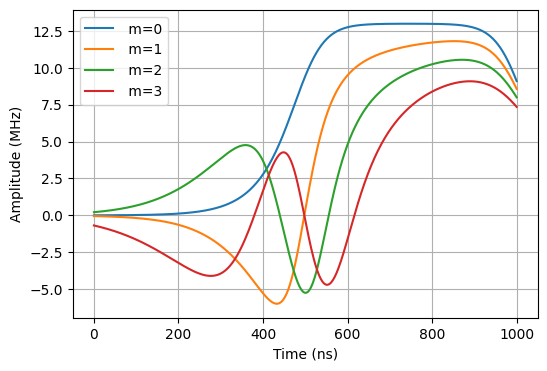

In [3]:
kappa =  0.14*2*np.pi
kappa_ph = 2.5e-3*2*np.pi*2
# t_vals = np.linspace(-500, 500, 501)
t_vals = np.linspace(0, 1000, 501)

def f(t, m, kappa):
    return xi_m(t-(t_vals[-1]-t_vals[0])/2, m, kappa)

def f_prime(t, m, kappa, h=1e-3):
    return (f(t + h, m, kappa) - f(t - h, m, kappa)) / (2 * h)

def compute_g(t_vals, m, kappa, kappa_ph):
    f_vals = f(t_vals, m, kappa_ph)
    f_prime_vals = f_prime(t_vals, m, kappa_ph)
    

    f2_vals = np.abs(f_vals)**2
    integral_vals = cumulative_trapezoid(f2_vals, t_vals, initial=0)
    
    numerator = f_prime_vals + (kappa * f_vals / 2)
    denominator = np.sqrt(kappa * (1 - integral_vals) - f2_vals)
    
    return numerator / denominator

plt.figure(figsize=(6, 4))
for m in range(4):
    g_vals = compute_g(t_vals, m, kappa, kappa_ph)
    plt.plot(t_vals, np.real(g_vals)/2/np.pi*1e3, label=fr" m={m}")

plt.xlabel("Time (ns)")
plt.ylabel("Amplitude (MHz)")
plt.legend()
plt.grid(True)
plt.show()


## QuTiP simulation

In [4]:
n_cutoff_q = 3
n_cutoff_r = 2
n_cutoff_vc = 3

b = qt.tensor(qt.destroy(n_cutoff_q), qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
a = qt.tensor(qt.qeye(n_cutoff_q), qt.destroy(n_cutoff_r), qt.qeye(n_cutoff_vc))
vc = qt.tensor(qt.qeye(n_cutoff_q), qt.qeye(n_cutoff_r), qt.destroy(n_cutoff_vc))

zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[0,1]=1
gedecayop=Qobj(zeromatrixxtmp)
etog = qt.tensor(gedecayop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[1,2]=1
efdecayop=Qobj(zeromatrixxtmp)
ftoe = qt.tensor(efdecayop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[0,0]=-1
zeromatrixxtmp[1,1]=1
gedechoop=Qobj(zeromatrixxtmp)
dechoge = qt.tensor(gedechoop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[1,1]=-1
zeromatrixxtmp[2,2]=1
efdechoop=Qobj(zeromatrixxtmp)
dechoef = qt.tensor(efdechoop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))

g0 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0))
f0 = qt.tensor(qt.basis(n_cutoff_q, 2), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0))
g1 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 1), qt.basis(n_cutoff_vc, 0))
e0 = qt.tensor(qt.basis(n_cutoff_q, 1), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0))
vc1 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 1))

alpha = -0.356 * 2 * np.pi
chi = -0.0076 * 2 * np.pi
eta = 0.67
kappa_r = 0.14 * 2 * np.pi
K = 0 * 2 * np.pi

H_fogi = (
    -alpha / 2 * b.dag()*b + alpha * b.dag()*b.dag()*b*b / 2
    +K * a.dag()*a.dag()*a*a / 2 + 2*chi*a.dag()*a*b.dag()*b
)

H_d = -a.dag()*b*b/np.sqrt(2)
H_c = 1j * (np.sqrt(kappa_r)/2) * vc.dag()*a

T1ge=29*1e3
T1ef=22*1e3
T2ge=5*1e3
T2ef=5*1e3
Tphige=1/((1/T2ge-1/T1ge/2)/2)
Tphief=1/((1/T2ef-1/T1ef/2)/2)

e_ops = []
options = qt.Options(atol=1e-9, rtol=1e-9, nsteps=1000, max_step=0.1, store_states=True)

c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


In [5]:
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d

T = 500 
N = 251
# tgrid = np.linspace(-T, T, N)
tgrid = np.linspace(0, 2*T, N)
dt = tgrid[1] - tgrid[0]
kappa_ph = 2.5e-3 * 2 * np.pi * 2

_eps = 1e-14

g_interps = []
g_interps_rvs = []

for m in range(4): 
    f_vals = f(tgrid, m, kappa_ph)
    f_prime_vals = f_prime(tgrid, m, kappa_ph) 
    f2_vals = np.abs(f_vals)**2
    integral_vals = cumulative_trapezoid(f2_vals, tgrid, initial=0)

    # numerator = f_prime_vals + (kappa_r * f_vals / 2)
    # denominator = np.sqrt(kappa_r * (1.0 - integral_vals) - f2_vals)
    numerator =  (kappa_r * f_vals / 2)
    denominator = np.sqrt(kappa_r * (1.0 - integral_vals))
    g_vals = numerator / denominator
    g_interp = interp1d(tgrid, np.real(g_vals), kind='cubic', fill_value='extrapolate')
    g_interps.append(g_interp)

    g_interp_rvs = interp1d(tgrid, np.real(g_vals[::-1]), kind='cubic', fill_value='extrapolate') 
    g_interps_rvs.append(g_interp_rvs)
    
g_u_interps = []
for m in range(4):
    ut_vals = xi_m(tgrid-(t_vals[-1]-t_vals[0])/2, m, kappa_ph) #` fix me
    cumint = cumulative_trapezoid(np.abs(ut_vals)**2, tgrid, initial=0)
    eps = 1e-14
    denom = np.sqrt(1.0 - cumint + eps)
    g_vals = np.conjugate(ut_vals) / denom
    g_interp = interp1d(tgrid, g_vals, kind='cubic', fill_value='extrapolate')
    g_u_interps.append(g_interp)
    
def g_u(t, args):
    m = int(args["input_num"])
    t_local = float(t)- float(args["center"])
    return float(args["g_u_interps"][m](t_local))

def g_u_conj(t, args):
    return np.conjugate(g_u(t, args))


def g_time(t, args):
    t_local = float(t) - float(args["center"])
    m = int(args["fogi_mode"])
    # access interpolant precomputed above (we'll pass lists via args)
    return float(args["g_interps"][m](t_local))

def g_time_conj(t, args):
    return np.conjugate(g_time(t, args))

def g_time_rvs(t, args):
    t_local = float(t) - float(args["center"])
    m = int(args["fogi_mode"])
    # access interpolant precomputed above (we'll pass lists via args)
    return float(args["g_interps_rvs"][m](t_local))

def g_time_conj_rvs(t, args):
    return np.conjugate(g_time_rvs(t, args))

kappa_ph = 2.5e-3 * 2 * np.pi * 2
g_v_interps = []
for m in range(4):
    ut_vals = xi_m(tgrid-(t_vals[-1]-t_vals[0])/2, m, kappa_ph)
    cumint = cumulative_trapezoid(np.abs(ut_vals)**2, tgrid, initial=0)
    eps = 1e-14
    denom = np.sqrt(1.0 - cumint + eps)
    g_vals = np.conjugate(ut_vals) / denom

    g_v_interp = interp1d(tgrid, -np.real(g_vals[::-1]), kind='cubic', fill_value='extrapolate') 
    g_v_interps.append(g_v_interp)


In [6]:
l=0
base_args = {
    "center": 0,
    "fogi_mode": 3,
    "g_interps": g_interps,
    "g_interps_rvs": g_interps_rvs,
    "g_u_interps": g_u_interps,
    "g_v_interps": g_v_interps,
    "input_num": 0,
    "output_num": 0,
    "input": 1,
}

initial_states = {
    "g0": g0,
    "vc1": vc1,
    "g0+vc1": (g0 + vc1).unit(),
    "g0-i*vc1": (g0 - 1j*vc1).unit(),
    "g0+i*vc1": (g0 + 1j*vc1).unit(),
    "g0-vc1": (g0 - vc1).unit()
}



In [23]:
results = {}

for m in range(4):
    for n in range(4):

        if m == n:
            print(f"Skipping (m, n) = ({m}, {n})")
            continue

        print(f"=== Starting simulation for (m, n) = ({m}, {n}) ===")

        for label, psi0_m in initial_states.items():

            args_mn = base_args.copy()
            args_mn["input_num"]  = m
            args_mn["fogi_mode"]  = n
            args_mn["output_num"] = m

            H_m = [
                H_fogi,
                [H_c, g_u], [H_c.dag(), g_u_conj],
                [H_d, g_time_rvs], [H_d.dag(), g_time_conj_rvs],
                [H_co, g_v_conj], [H_co.dag(), g_v],
                [H_cco, g_u_v], [H_cco.dag(), g_u_v_conj],
            ]

            def total_c_op(t, args):
                return (np.conjugate(g_u(t, args)) * vc
                        + np.conjugate(g_v(t, args)) * vco
                        + np.sqrt(kappa_r) * a)

            c_ops_mn = [
                total_c_op,
                np.sqrt(1/T1ge)*etog, np.sqrt(1/T1ef)*ftoe,
                np.sqrt(1/Tphige)*dechoge, np.sqrt(1/Tphief)*dechoef
            ]

            result_mn = qt.mesolve(
                H_m, psi0_m, tgrid - tgrid[0], c_ops_mn,
                e_ops=e_ops, args=args_mn,
                options=options, progress_bar=True
            )

            results[(m, n, label)] = result_mn
            print(f"Finished simulation for (m,n,label)=({m},{n},{label})")

# import json
# with h5py.File("results_output_qstate.h5", "w") as f:
#     for (m, n, label), result_mn in results.items():

#         group_name = f"m{m}/n{n}/{label}"
#         grp = f.create_group(group_name)

#         for ti, rho in enumerate(result_mn.states):
#             sgrp = grp.create_group(f"state_{ti}")

#             sgrp.create_dataset("data", data=rho.full())

#             sgrp.attrs["dims"] = json.dumps(rho.dims)


Skipping (m, n) = (0, 0)
=== Starting simulation for (m, n) = (0, 1) ===


c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\solver\solver_base.py:501: FutureWarning: "progress_bar" is now included in options:
 Use `options={"progress_bar": False / True / "tqdm" / "enhanced"}`
  warnings.warn(


10.0%. Run time:   0.70s. Est. time left: 00:00:00:06
20.0%. Run time:   1.37s. Est. time left: 00:00:00:05
30.0%. Run time:   2.07s. Est. time left: 00:00:00:04
40.0%. Run time:   2.73s. Est. time left: 00:00:00:04
50.0%. Run time:   3.41s. Est. time left: 00:00:00:03
60.0%. Run time:   4.04s. Est. time left: 00:00:00:02
70.0%. Run time:   4.65s. Est. time left: 00:00:00:01
80.0%. Run time:   5.30s. Est. time left: 00:00:00:01
90.0%. Run time:   6.01s. Est. time left: 00:00:00:00
100.0%. Run time:   6.71s. Est. time left: 00:00:00:00
Total run time:   6.71s
Finished simulation for (m,n,label)=(0,1,g0)
10.0%. Run time:   0.72s. Est. time left: 00:00:00:06
20.0%. Run time:   1.48s. Est. time left: 00:00:00:05
30.0%. Run time:   2.19s. Est. time left: 00:00:00:05
40.0%. Run time:   2.84s. Est. time left: 00:00:00:04
50.0%. Run time:   3.52s. Est. time left: 00:00:00:03
60.0%. Run time:   4.17s. Est. time left: 00:00:00:02
70.0%. Run time:   4.82s. Est. time left: 00:00:00:02
80.0%. Run t

Plotting m=0, n=1


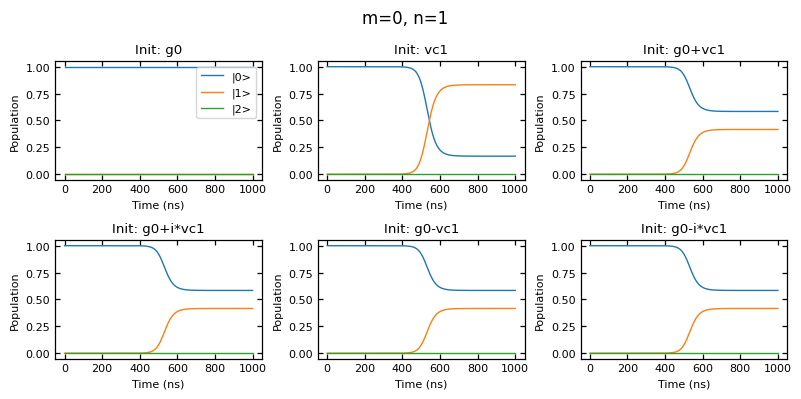

Plotting m=0, n=2


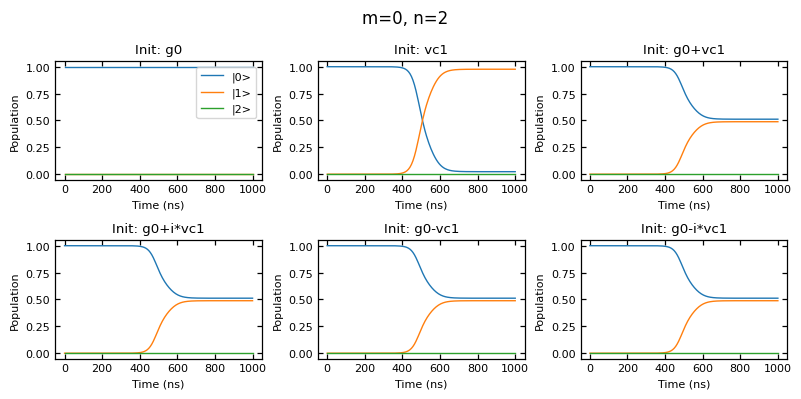

Plotting m=0, n=3


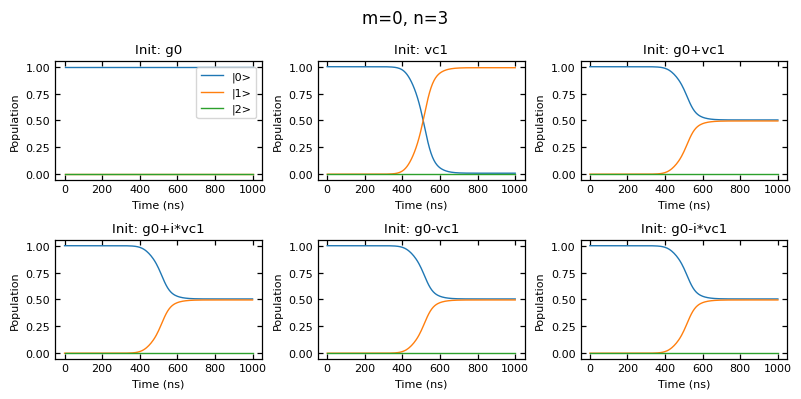

Plotting m=1, n=0


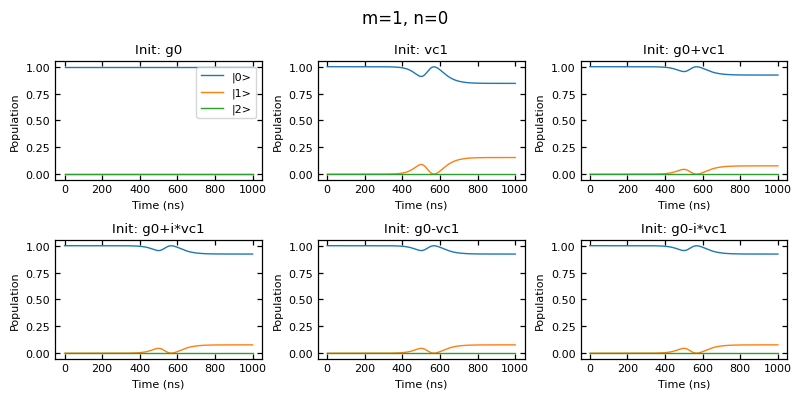

Plotting m=1, n=2


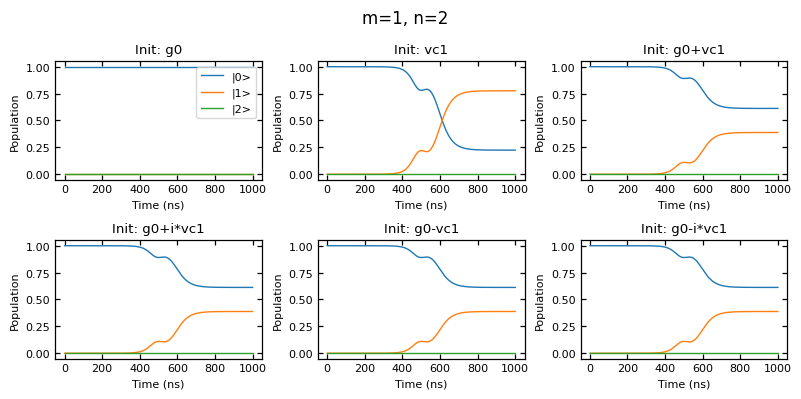

Plotting m=1, n=3


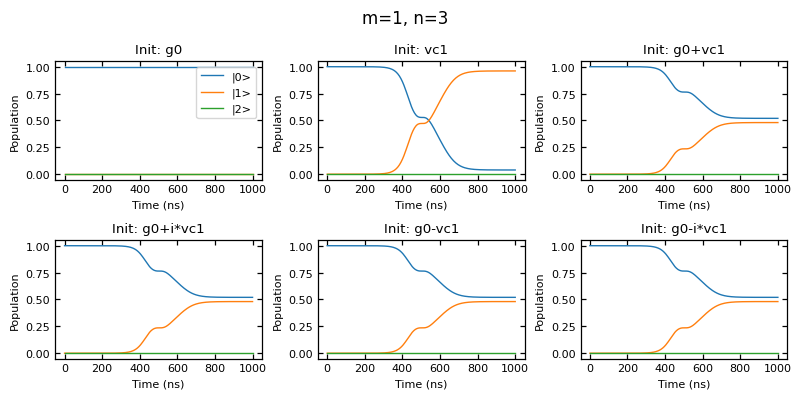

Plotting m=2, n=0


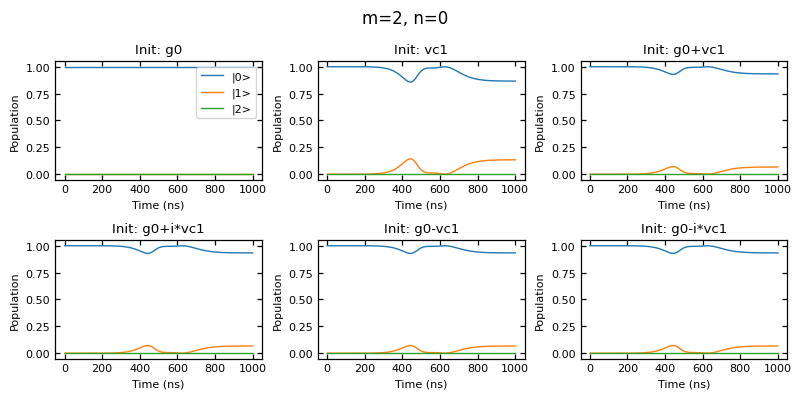

Plotting m=2, n=1


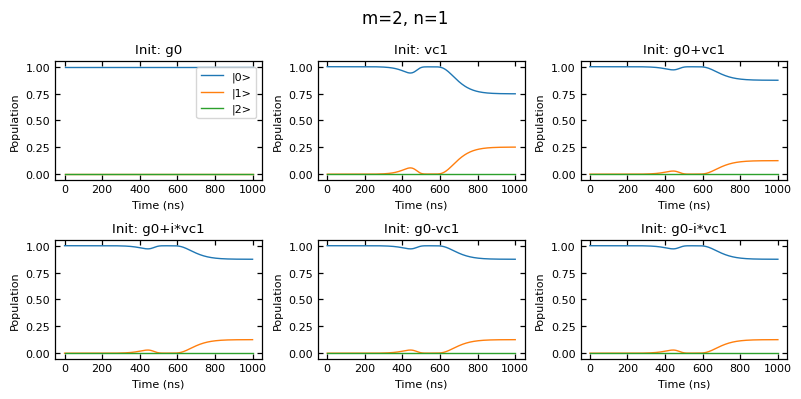

Plotting m=2, n=3


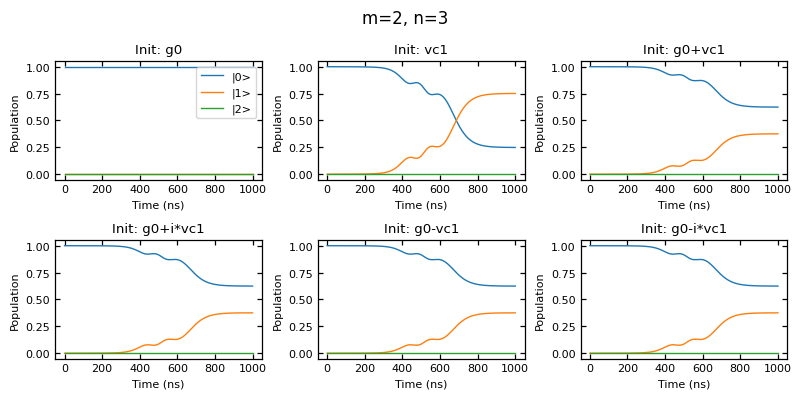

Plotting m=3, n=0


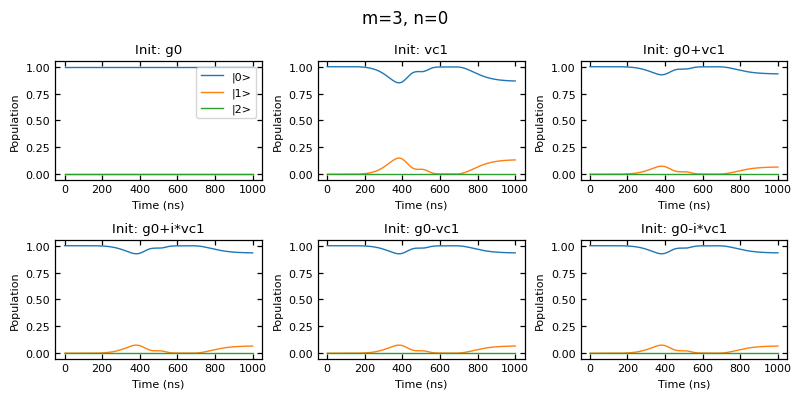

Plotting m=3, n=1


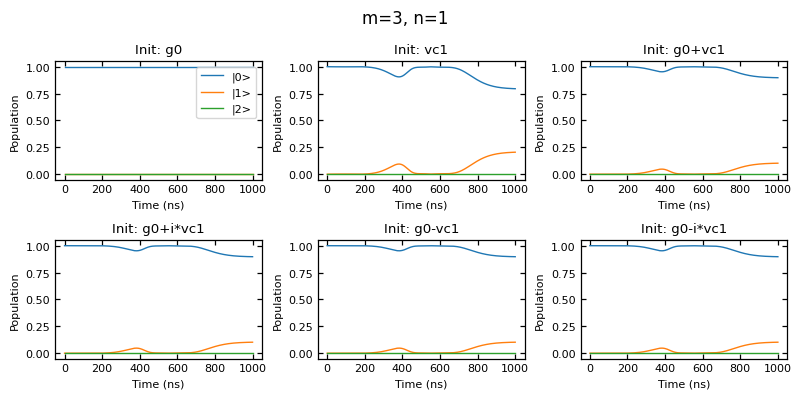

Plotting m=3, n=2


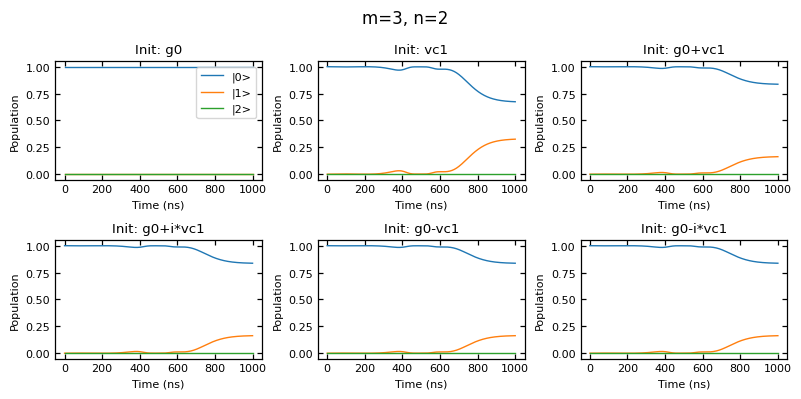

In [ ]:
import h5py, json
def load_all_states(filename, m, n, label):

    with h5py.File(filename, "r") as f:
        group = f[f"m{m}/n{n}/{label}"]
        keys = sorted(group.keys(), key=lambda s: int(s.split('_')[1]))
        states = []
        for k in keys:
            rho_data = group[k]["data"][()]
            dims = json.loads(group[k].attrs["dims"])
            states.append(qt.Qobj(rho_data, dims=dims))
    return states

filename = "results_output_qstate.h5"

initial_labels = ["g0", "vc1", "g0+vc1", "g0+i*vc1", "g0-vc1", "g0-i*vc1"]
e_labels = ["|0>", "|1>", "|2>"] 
target_mode = 3

for m in range(4):
    for n in range(4):
        if m == n:
            continue 
        
        print(f"Plotting m={m}, n={n}")

        fig, axes = plt.subplots(2, 3, figsize=(8, 4))
        axes = axes.ravel()

        for idx, label in enumerate(initial_labels):
            states = load_all_states(filename, m=m, n=n, label=label)
            tlist = np.arange(len(states)) * dt

            ax = axes[idx]
            for i, l in enumerate(e_labels):
                pop = [state.ptrace(target_mode).full()[i, i].real for state in states]
                ax.plot(tlist, pop, label=l)

            ax.set_title(f"Init: {label}")
            ax.set_xlabel("Time (ns)")
            ax.set_ylabel("Population")
            if idx == 0:
                ax.legend(fontsize=8)

        fig.suptitle(f"m={m}, n={n}", fontsize=12)
        plt.tight_layout()
        plt.show()

Plotting m=0, n=1


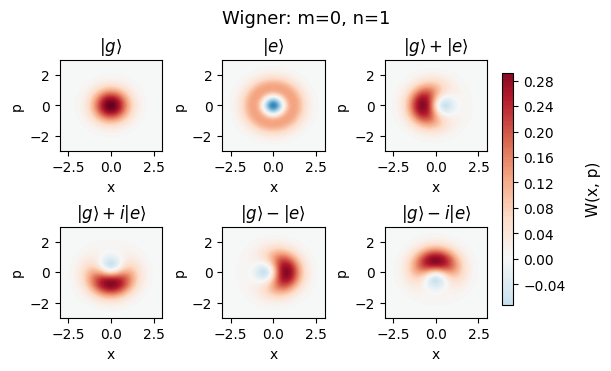

Plotting m=0, n=2


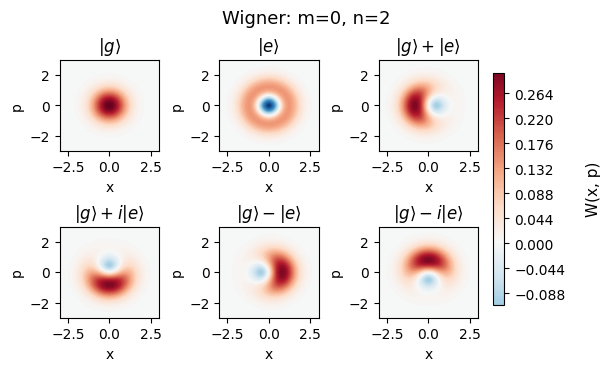

Plotting m=0, n=3


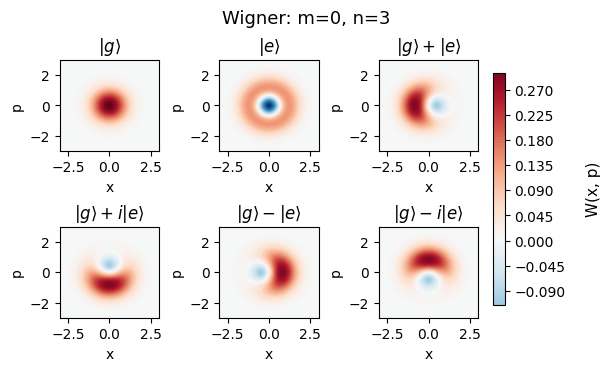

Plotting m=1, n=0


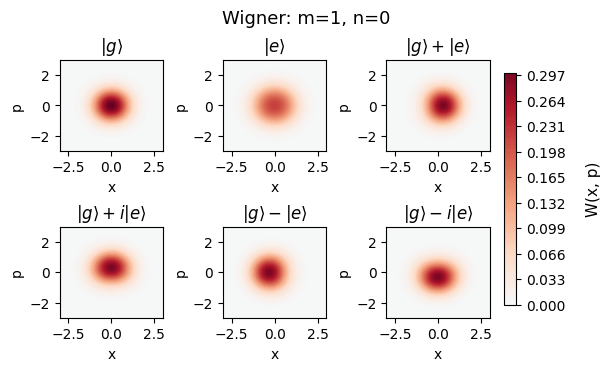

Plotting m=1, n=2


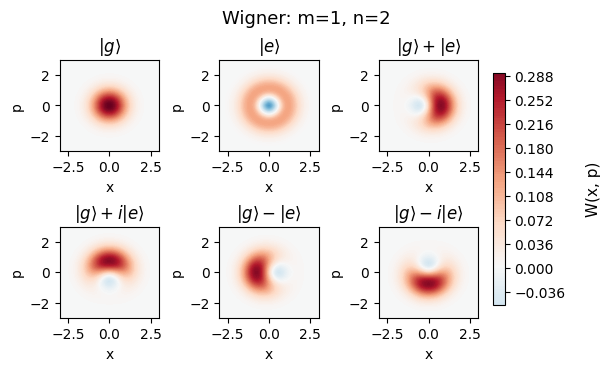

Plotting m=1, n=3


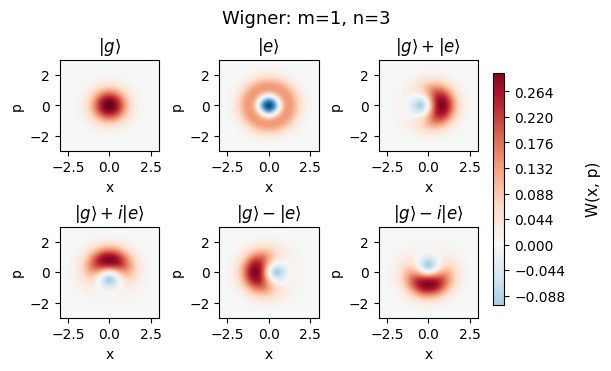

Plotting m=2, n=0


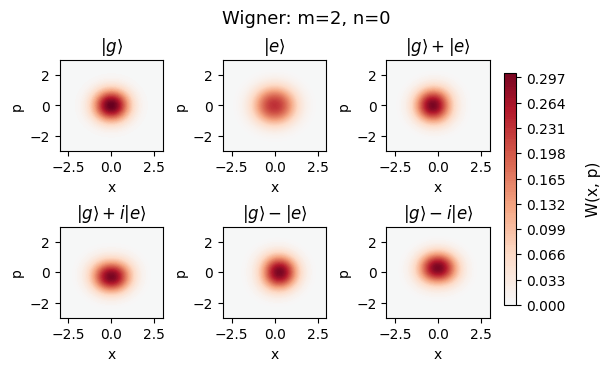

Plotting m=2, n=1


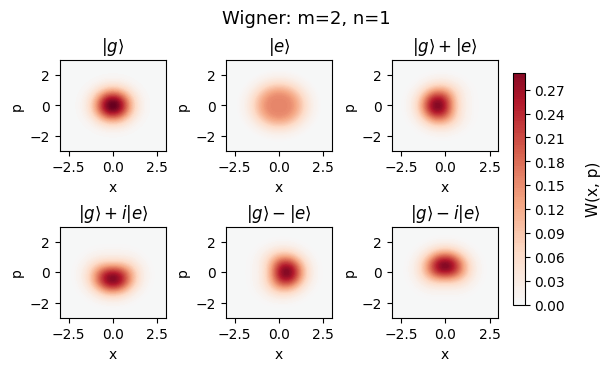

Plotting m=2, n=3


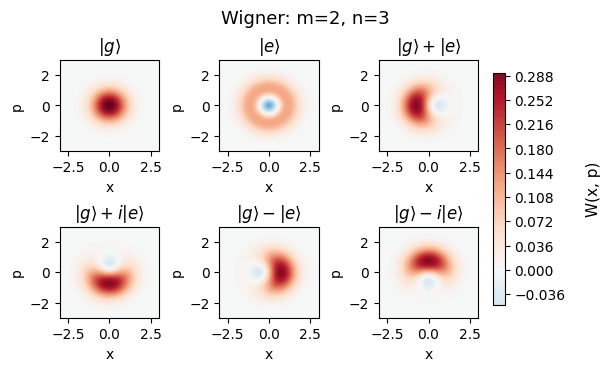

Plotting m=3, n=0


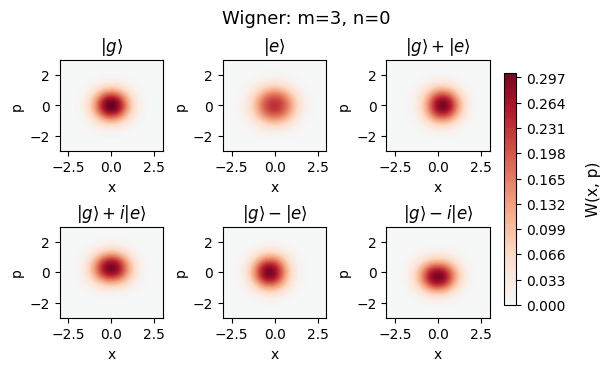

Plotting m=3, n=1


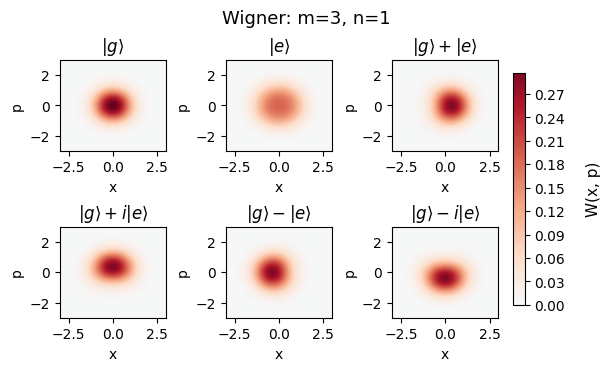

Plotting m=3, n=2


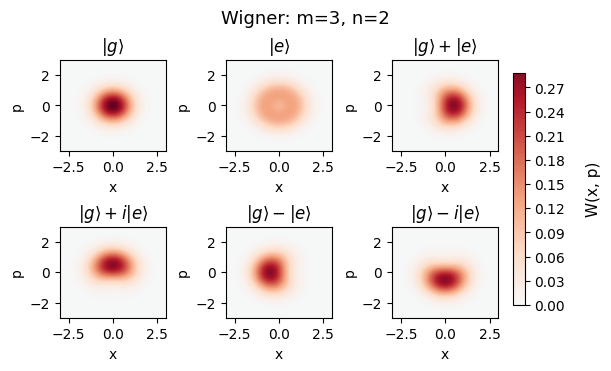

In [14]:
filename = "results_output_qstate.h5"
import h5py, json

def load_final_state(filename, m, n, label):
    with h5py.File(filename, "r") as f:
        group = f[f"m{m}/n{n}/{label}"]
        keys = sorted(group.keys(), key=lambda s: int(s.split('_')[1]))
        last = group[keys[-1]]

        rho_data = last["data"][()]
        dims = json.loads(last.attrs["dims"])

        return qt.Qobj(rho_data, dims=dims)

xvec = np.linspace(-3, 3, 200)
initial_labels = ["g0", "vc1", "g0+vc1", "g0+i*vc1", "g0-vc1", "g0-i*vc1"]
initial_labels_tex = [r"$|g\rangle$", r"$|e\rangle$", r"$|g\rangle+|e\rangle$", 
                      r"$|g\rangle+i|e\rangle$", r"$|g\rangle-|e\rangle$", r"$|g\rangle-i|e\rangle$"]

m=0
n=3
W_all = []
for label in initial_labels:
    rho_total = load_final_state(filename, m, n, label)
    rho_vco = rho_total.ptrace(3)
    W_vco = qt.wigner(rho_vco, xvec, xvec)
    W_all.append(W_vco)

W_stack = np.array(W_all)
vmin, vmax = W_stack.min(), W_stack.max()

for m in range(4):
    for n in range(4):
        if m == n:
            continue

        print(f"Plotting m={m}, n={n}")

        W_all = []
        for label in initial_labels:
            rho_total = load_final_state(filename, m, n, label)
            rho_vco = rho_total.ptrace(3)
            W_vco = qt.wigner(rho_vco, xvec, xvec)
            W_all.append(W_vco)


        fig, axes = plt.subplots(2, 3, figsize=(6, 3.6), constrained_layout=True)
        axes = axes.ravel()

        for i, label in enumerate(initial_labels_tex):
            W_vco = W_all[i]
            im = axes[i].contourf(
                xvec, xvec, W_vco, 100, cmap="RdBu_r",
                vmin=vmin, vmax=vmax
            )
            axes[i].set_title(label)
            axes[i].set_xlabel("x")
            axes[i].set_ylabel("p")

        cbar = fig.colorbar(im, ax=axes, orientation="vertical",
                            shrink=0.9, pad=0.03)
        cbar.set_label("W(x, p)", rotation=90, labelpad=15, fontsize=11)

        fig.suptitle(f"Wigner: m={m}, n={n}", fontsize=13)

        plt.show()

===== m=0, n=1 =====
→ Using initial_labels_pi (sign flipped order)


c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))
C:\Users\qipe\AppData\Local\Temp\ipykernel_8824\329137254.py:125: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


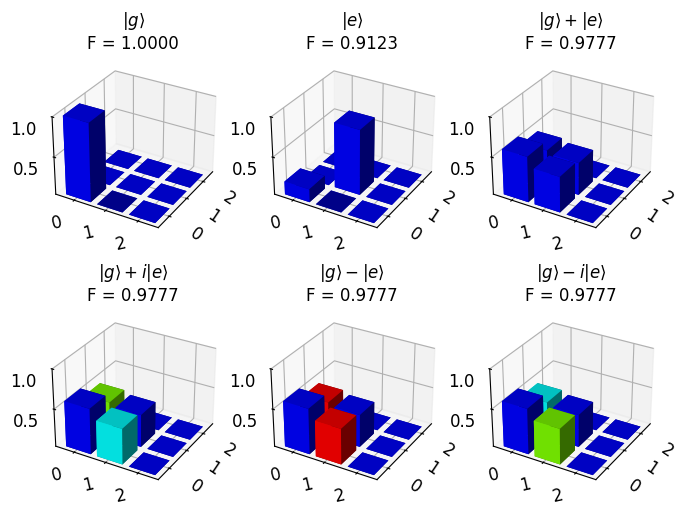

<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)
<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)


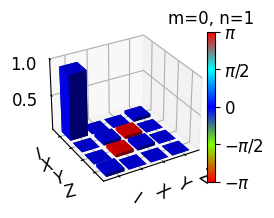

chi : [[ 9.14043735e-01+0.00000000e+00j  1.38777878e-17+8.34748937e-14j
  -8.34748937e-14-1.38777878e-17j  4.19439686e-02+0.00000000e+00j]
 [ 1.38777878e-17-8.34748937e-14j  4.19439686e-02+0.00000000e+00j
  -4.19439686e-02+0.00000000e+00j  8.34748937e-14-1.38777878e-17j]
 [-8.34748937e-14+1.38777878e-17j -4.19439686e-02+0.00000000e+00j
   4.19439686e-02+0.00000000e+00j -1.38777878e-17+8.34748937e-14j]
 [ 4.19439686e-02+0.00000000e+00j  8.34748937e-14+1.38777878e-17j
  -1.38777878e-17-8.34748937e-14j  2.06832746e-03+0.00000000e+00j]]
Process fidelity : 0.91404
Process chi fidelity : 0.91404+0.00000j
===== m=0, n=2 =====
→ Using initial_labels_pi (sign flipped order)


c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))
C:\Users\qipe\AppData\Local\Temp\ipykernel_8824\329137254.py:125: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


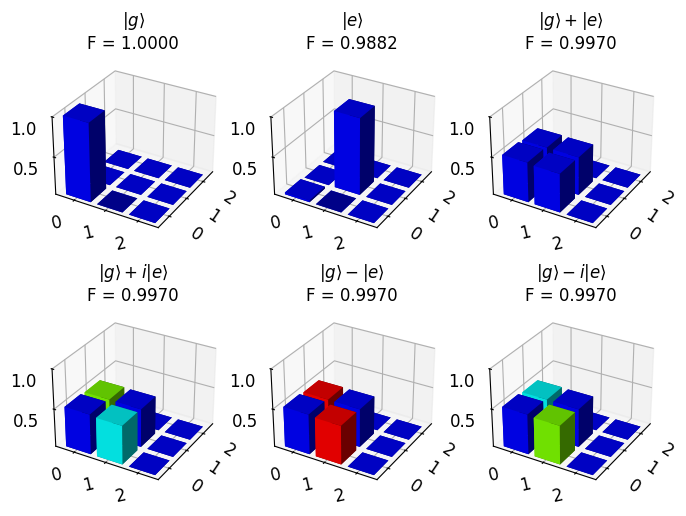

<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)
<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)


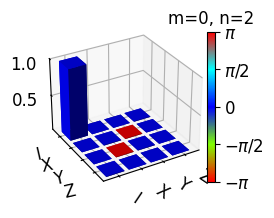

chi : [[ 9.88223878e-01+0.00000000e+00j -4.16333634e-17+4.04537515e-14j
  -4.04537515e-14+4.16333634e-17j  5.86537309e-03+0.00000000e+00j]
 [-4.16333634e-17-4.04537515e-14j  5.86537309e-03+0.00000000e+00j
  -5.86537309e-03+0.00000000e+00j  4.04537515e-14+4.16333634e-17j]
 [-4.04537515e-14-4.16333634e-17j -5.86537309e-03+0.00000000e+00j
   5.86537309e-03+0.00000000e+00j  4.16333634e-17+4.04537515e-14j]
 [ 5.86537309e-03+0.00000000e+00j  4.04537515e-14-4.16333634e-17j
   4.16333634e-17-4.04537515e-14j  4.53756648e-05+0.00000000e+00j]]
Process fidelity : 0.98822
Process chi fidelity : 0.98822+0.00000j
===== m=0, n=3 =====
→ Using initial_labels_pi (sign flipped order)


c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))
C:\Users\qipe\AppData\Local\Temp\ipykernel_8824\329137254.py:125: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


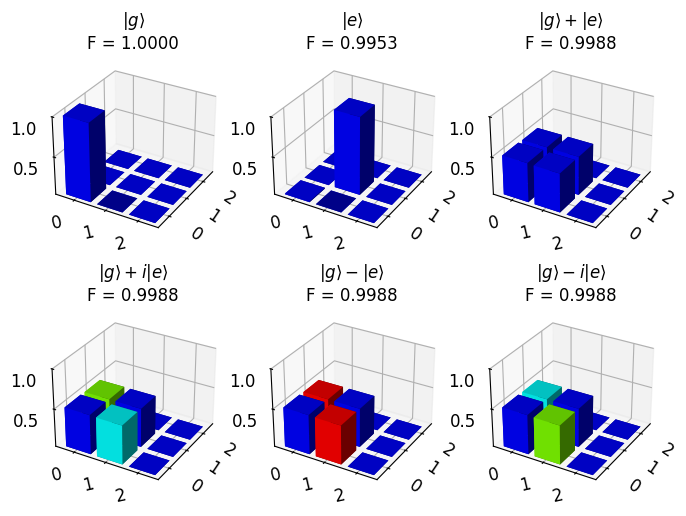

<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)
<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)


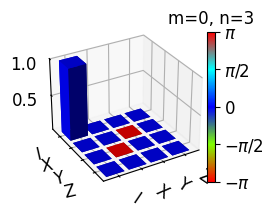

chi : [[ 9.95331354e-01+0.00000000e+00j -4.16333634e-17+3.37230244e-15j
  -3.37230244e-15+4.16333634e-17j  2.32984335e-03+0.00000000e+00j]
 [-4.16333634e-17-3.37230244e-15j  2.32984335e-03+0.00000000e+00j
  -2.32984335e-03+0.00000000e+00j  3.37230244e-15+4.16333634e-17j]
 [-3.37230244e-15-4.16333634e-17j -2.32984335e-03+0.00000000e+00j
   2.32984335e-03+0.00000000e+00j  4.16333634e-17+3.37230244e-15j]
 [ 2.32984335e-03+0.00000000e+00j  3.37230244e-15-4.16333634e-17j
   4.16333634e-17-3.37230244e-15j  8.95931665e-06+0.00000000e+00j]]
Process fidelity : 0.99533
Process chi fidelity : 0.99533+0.00000j
===== m=1, n=0 =====
→ Using initial_labels (normal order)


c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))
C:\Users\qipe\AppData\Local\Temp\ipykernel_8824\329137254.py:125: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


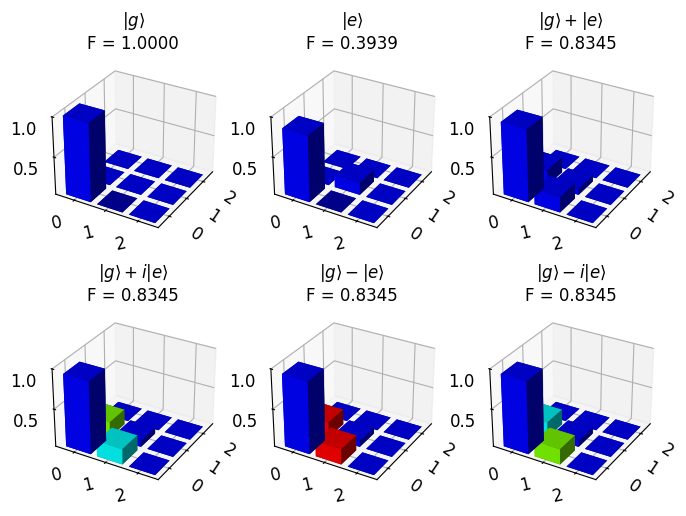

<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)
<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)


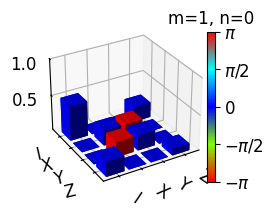

chi : [[ 4.85159327e-01+0.00000000e+00j -1.04083409e-17+2.90982516e-14j
  -2.90982516e-14+1.04083409e-17j  2.11211235e-01+0.00000000e+00j]
 [-1.04083409e-17-2.90982516e-14j  2.11211235e-01+0.00000000e+00j
  -2.11211235e-01+0.00000000e+00j  2.90982516e-14+1.04083409e-17j]
 [-2.90982516e-14-1.04083409e-17j -2.11211235e-01+0.00000000e+00j
   2.11211235e-01+0.00000000e+00j  1.04083409e-17+2.90982516e-14j]
 [ 2.11211235e-01+0.00000000e+00j  2.90982516e-14-1.04083409e-17j
   1.04083409e-17-2.90982516e-14j  9.24182034e-02+0.00000000e+00j]]
Process fidelity : 0.48516
Process chi fidelity : 0.48516+0.00000j
===== m=1, n=2 =====
→ Using initial_labels (normal order)


c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))
C:\Users\qipe\AppData\Local\Temp\ipykernel_8824\329137254.py:125: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


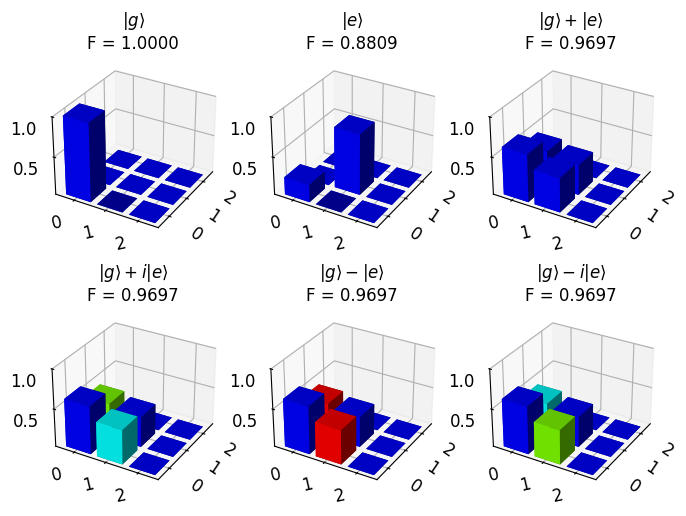

<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)
<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)


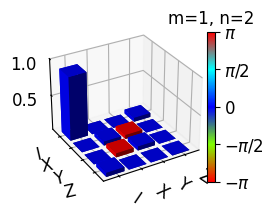

chi : [[ 8.84275173e-01+0.00000000e+00j -6.93889390e-17-4.22425983e-13j
   4.22425983e-13+6.93889390e-17j  5.59902137e-02+0.00000000e+00j]
 [-6.93889390e-17+4.22425983e-13j  5.59902137e-02+0.00000000e+00j
  -5.59902137e-02+0.00000000e+00j -4.22425983e-13+6.93889390e-17j]
 [ 4.22425983e-13-6.93889390e-17j -5.59902137e-02+0.00000000e+00j
   5.59902137e-02+0.00000000e+00j  6.93889390e-17-4.22425983e-13j]
 [ 5.59902137e-02+0.00000000e+00j -4.22425983e-13-6.93889390e-17j
   6.93889390e-17+4.22425983e-13j  3.74439989e-03+0.00000000e+00j]]
Process fidelity : 0.88428
Process chi fidelity : 0.88428+0.00000j
===== m=1, n=3 =====
→ Using initial_labels (normal order)


c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))
C:\Users\qipe\AppData\Local\Temp\ipykernel_8824\329137254.py:125: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


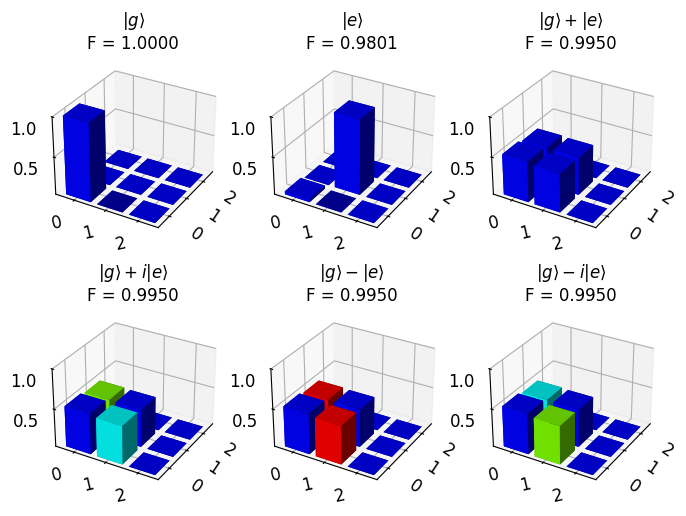

<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)
<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)


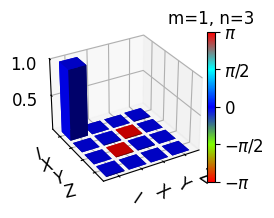

chi : [[ 9.80217871e-01+0.00000000e+00j  5.55111512e-17-9.81270620e-13j
   9.81270620e-13-5.55111512e-17j  9.82945464e-03+0.00000000e+00j]
 [ 5.55111512e-17+9.81270620e-13j  9.82945464e-03+0.00000000e+00j
  -9.82945464e-03+0.00000000e+00j -9.81270620e-13-5.55111512e-17j]
 [ 9.81270620e-13+5.55111512e-17j -9.82945464e-03+0.00000000e+00j
   9.82945464e-03+0.00000000e+00j -5.55111512e-17-9.81270620e-13j]
 [ 9.82945464e-03+0.00000000e+00j -9.81270620e-13+5.55111512e-17j
  -5.55111512e-17+9.81270620e-13j  1.23220175e-04+0.00000000e+00j]]
Process fidelity : 0.98022
Process chi fidelity : 0.98022+0.00000j
===== m=2, n=0 =====
→ Using initial_labels_pi (sign flipped order)


c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))
C:\Users\qipe\AppData\Local\Temp\ipykernel_8824\329137254.py:125: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


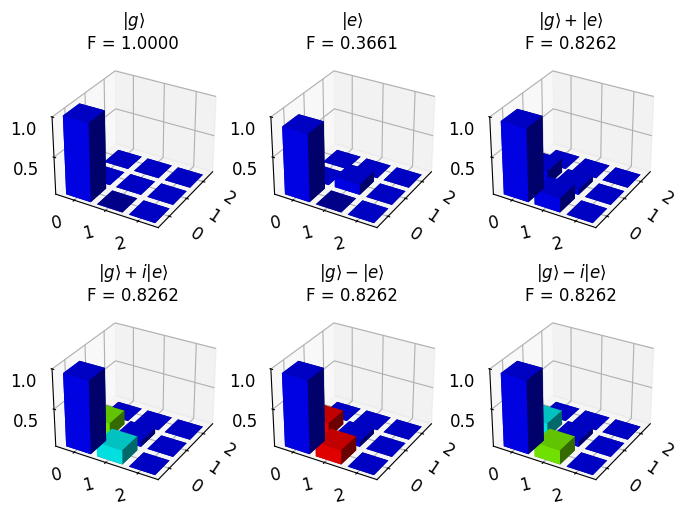

<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)
<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)


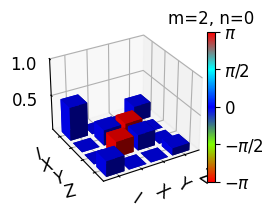

chi : [[ 4.66111655e-01+0.00000000e+00j  7.97972799e-17+5.10789328e-13j
  -5.10789328e-13-7.97972799e-17j  2.16484425e-01+0.00000000e+00j]
 [ 7.97972799e-17-5.10789328e-13j  2.16484425e-01+0.00000000e+00j
  -2.16484425e-01+0.00000000e+00j  5.10789328e-13-7.97972799e-17j]
 [-5.10789328e-13+7.97972799e-17j -2.16484425e-01+0.00000000e+00j
   2.16484425e-01+0.00000000e+00j -7.97972799e-17+5.10789328e-13j]
 [ 2.16484425e-01+0.00000000e+00j  5.10789328e-13+7.97972799e-17j
  -7.97972799e-17-5.10789328e-13j  1.00919495e-01+0.00000000e+00j]]
Process fidelity : 0.46611
Process chi fidelity : 0.46611+0.00000j
===== m=2, n=1 =====
→ Using initial_labels_pi (sign flipped order)


c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))
C:\Users\qipe\AppData\Local\Temp\ipykernel_8824\329137254.py:125: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


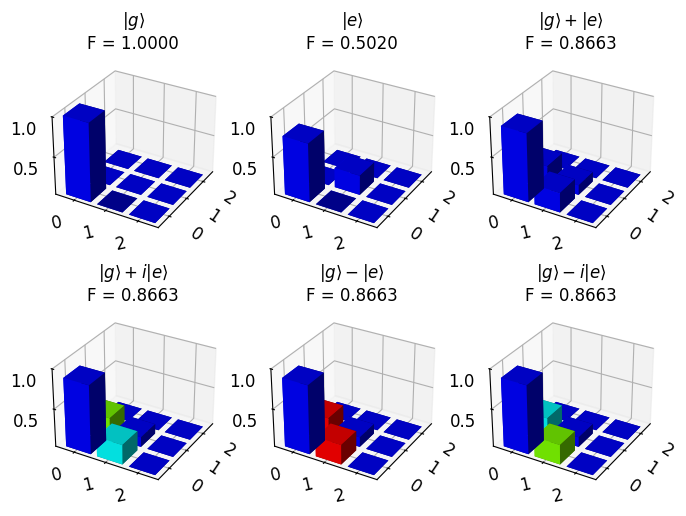

<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)
<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)


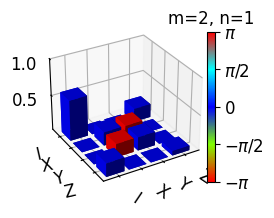

chi : [[ 5.63424327e-01+0.00000000e+00j -6.24500451e-17-1.70751607e-12j
   1.70751607e-12+6.24500451e-17j  1.87011313e-01+0.00000000e+00j]
 [-6.24500451e-17+1.70751607e-12j  1.87011313e-01+0.00000000e+00j
  -1.87011313e-01+0.00000000e+00j -1.70751607e-12+6.24500451e-17j]
 [ 1.70751607e-12-6.24500451e-17j -1.87011313e-01+0.00000000e+00j
   1.87011313e-01+0.00000000e+00j  6.24500451e-17-1.70751607e-12j]
 [ 1.87011313e-01+0.00000000e+00j -1.70751607e-12-6.24500451e-17j
   6.24500451e-17+1.70751607e-12j  6.25530463e-02+0.00000000e+00j]]
Process fidelity : 0.56342
Process chi fidelity : 0.56342+0.00000j
===== m=2, n=3 =====
→ Using initial_labels_pi (sign flipped order)


c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))
C:\Users\qipe\AppData\Local\Temp\ipykernel_8824\329137254.py:125: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


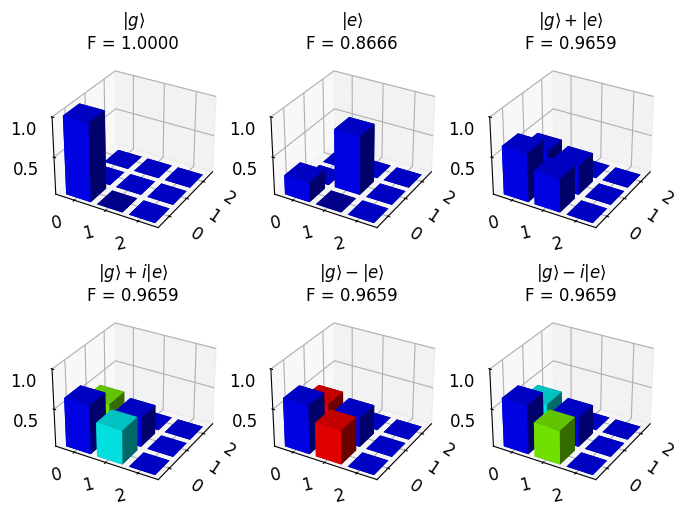

<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)
<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)


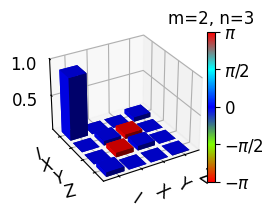

chi : [[ 8.70817878e-01+0.00000000e+00j -2.77555756e-17-1.35327860e-12j
   1.35327860e-12+2.77555756e-17j  6.22374916e-02+0.00000000e+00j]
 [-2.77555756e-17+1.35327860e-12j  6.22374916e-02+0.00000000e+00j
  -6.22374916e-02+0.00000000e+00j -1.35327860e-12+2.77555756e-17j]
 [ 1.35327860e-12-2.77555756e-17j -6.22374916e-02+0.00000000e+00j
   6.22374916e-02+0.00000000e+00j  2.77555756e-17-1.35327860e-12j]
 [ 6.22374916e-02+0.00000000e+00j -1.35327860e-12-2.77555756e-17j
   2.77555756e-17+1.35327860e-12j  4.70713886e-03+0.00000000e+00j]]
Process fidelity : 0.87082
Process chi fidelity : 0.87082+0.00000j
===== m=3, n=0 =====
→ Using initial_labels (normal order)


c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))
C:\Users\qipe\AppData\Local\Temp\ipykernel_8824\329137254.py:125: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


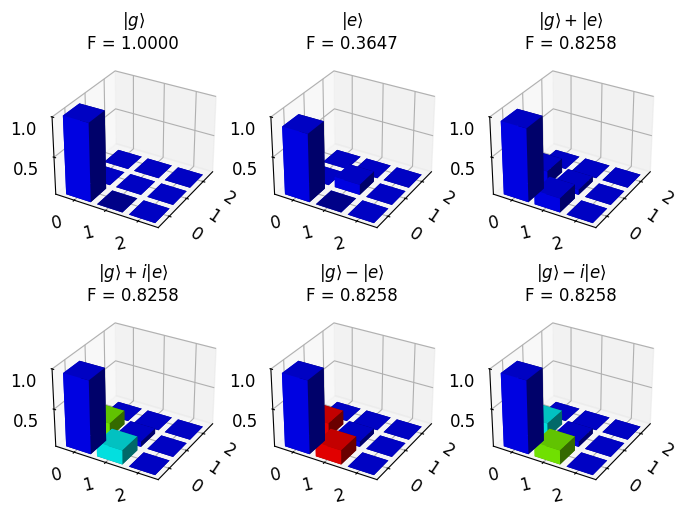

<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)
<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)


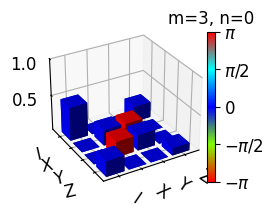

chi : [[ 4.65189698e-01+0.00000000e+00j -6.59194921e-17+1.21897978e-12j
  -1.21897978e-12+6.59194921e-17j  2.16742584e-01+0.00000000e+00j]
 [-6.59194921e-17-1.21897978e-12j  2.16742584e-01+0.00000000e+00j
  -2.16742584e-01+0.00000000e+00j  1.21897978e-12+6.59194921e-17j]
 [-1.21897978e-12-6.59194921e-17j -2.16742584e-01+0.00000000e+00j
   2.16742584e-01+0.00000000e+00j  6.59194921e-17+1.21897978e-12j]
 [ 2.16742584e-01+0.00000000e+00j  1.21897978e-12-6.59194921e-17j
   6.59194921e-17-1.21897978e-12j  1.01325135e-01+0.00000000e+00j]]
Process fidelity : 0.46519
Process chi fidelity : 0.46519+0.00000j
===== m=3, n=1 =====
→ Using initial_labels (normal order)


c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))
C:\Users\qipe\AppData\Local\Temp\ipykernel_8824\329137254.py:125: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


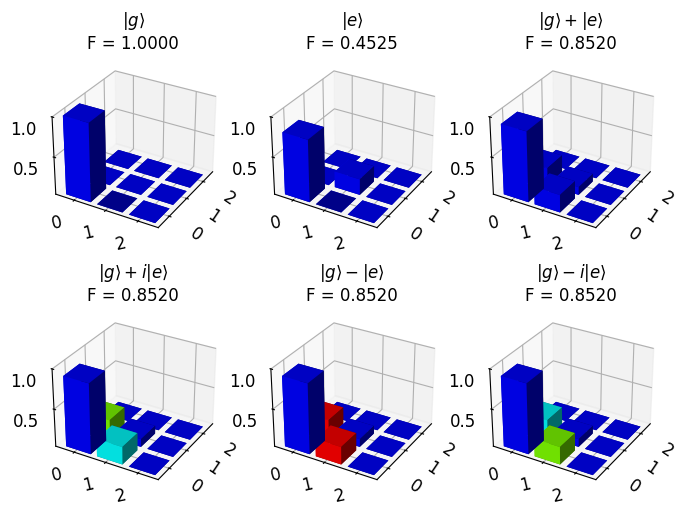

<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)
<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)


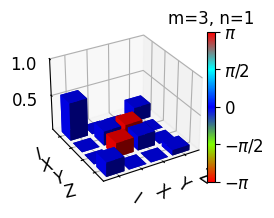

chi : [[ 5.27033485e-01+0.00000000e+00j -4.16333634e-17+4.17929580e-13j
  -4.17929580e-13+4.16333634e-17j  1.98821335e-01+0.00000000e+00j]
 [-4.16333634e-17-4.17929580e-13j  1.98821335e-01+0.00000000e+00j
  -1.98821335e-01+0.00000000e+00j  4.17929580e-13+4.16333634e-17j]
 [-4.17929580e-13-4.16333634e-17j -1.98821335e-01+0.00000000e+00j
   1.98821335e-01+0.00000000e+00j  4.16333634e-17+4.17929580e-13j]
 [ 1.98821335e-01+0.00000000e+00j  4.17929580e-13-4.16333634e-17j
   4.16333634e-17-4.17929580e-13j  7.53238437e-02+0.00000000e+00j]]
Process fidelity : 0.52703
Process chi fidelity : 0.52703+0.00000j
===== m=3, n=2 =====
→ Using initial_labels (normal order)


c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))
C:\Users\qipe\AppData\Local\Temp\ipykernel_8824\329137254.py:125: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


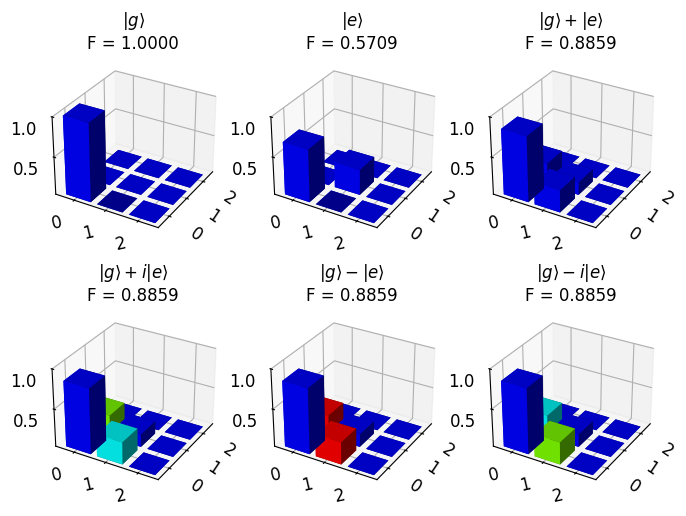

<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)
<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)


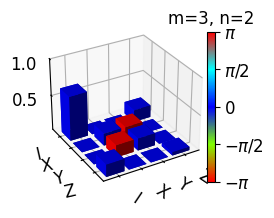

chi : [[ 6.16370902e-01+0.00000000e+00j -4.16333634e-17+7.89798782e-13j
  -7.89798782e-13+4.16333634e-17j  1.68517410e-01+0.00000000e+00j]
 [-4.16333634e-17-7.89798782e-13j  1.68517410e-01+0.00000000e+00j
  -1.68517410e-01+0.00000000e+00j  7.89798782e-13+4.16333634e-17j]
 [-7.89798782e-13-4.16333634e-17j -1.68517410e-01+0.00000000e+00j
   1.68517410e-01+0.00000000e+00j  4.16333634e-17+7.89798782e-13j]
 [ 1.68517410e-01+0.00000000e+00j  7.89798782e-13-4.16333634e-17j
   4.16333634e-17-7.89798782e-13j  4.65942776e-02+0.00000000e+00j]]
Process fidelity : 0.61637
Process chi fidelity : 0.61637+0.00000j


c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


In [16]:
from process_tomography import *
from state_tomography import *
from libys import qtp as ysq

initial_labels = ["g0", "vc1", "g0+vc1", "g0+i*vc1", "g0-vc1", "g0-i*vc1"]
initial_labels_tex = [r"$|g\rangle$", r"$|e\rangle$", r"$|g\rangle+|e\rangle$", 
                      r"$|g\rangle+i|e\rangle$", r"$|g\rangle-|e\rangle$", r"$|g\rangle-i|e\rangle$"]


def compute_fidelities_for_labelset(filename, m, n, initial_labels, ideals, target_mode):
    fidelities = {}
    reduced_qubits = {}
    rho_fulls = {}

    for label in initial_labels:
        rho_total = load_final_state(filename, m, n, label)

        try:
            rho_mode = rho_total.ptrace(target_mode)
        except Exception as e:
            print(f"ptrace failed for {label} with target_mode={target_mode}: {e}")
            rho_mode = rho_total

        rho_mode_mat = np.array(rho_mode.full(), dtype=complex)

        rho_3_mat = np.zeros((3, 3), dtype=complex)
        n_dim = min(rho_mode_mat.shape[0], 3)
        rho_3_mat[:n_dim, :n_dim] = rho_mode_mat[:n_dim, :n_dim]
        rho_3 = qt.Qobj(rho_3_mat, dims=[[3], [3]])

        reduced_qubits[label] = rho_3
        rho_fulls[label] = rho_mode

        if label in ideals:
            fid = float(qt.metrics.fidelity(rho_3, ideals[label]))
        else:
            fid = None

        fidelities[label] = fid

    total_fid = sum(f for f in fidelities.values() if f is not None)
    return total_fid, fidelities, reduced_qubits, rho_fulls


def evaluate_state_transfer_three_level(
    filename="results_output_qstate.h5",
    m=0, n=3,
    initial_labels=None,
    initial_labels_pi=None,
    target_mode=3,
    plot_results=True
):

    if initial_labels is None:
        initial_labels = ["g0", "vc1", "g0+vc1", "g0+i*vc1", "g0-vc1", "g0-i*vc1"]

    b0 = qt.basis(2, 0)
    b1 = qt.basis(2, 1)
    ideals_2 = {
        "g0": b0.proj(),
        "vc1": b1.proj(),
        "g0+vc1": (b0 + b1).unit().proj(),
        "g0+i*vc1": (b0 + 1j*b1).unit().proj(),
        "g0-vc1": (b0 - b1).unit().proj(),
        "g0-i*vc1": (b0 - 1j*b1).unit().proj(),
    }
    ideals = {}
    for k, rho2 in ideals_2.items():
        rho3_mat = np.zeros((3, 3), dtype=complex)
        rho3_mat[:2, :2] = rho2.full()  
        rho3_mat[2, 2] = 0.0 
        rho3 = qt.Qobj(rho3_mat, dims=[[3], [3]])  
        ideals[k] = rho3

    ideals_2_pi = {
        "g0": b0.proj(),
        "vc1": b1.proj(),
        "g0+vc1": (b0 - b1).unit().proj(),
        "g0+i*vc1": (b0 - 1j*b1).unit().proj(),
        "g0-vc1": (b0 + b1).unit().proj(),
        "g0-i*vc1": (b0 + 1j*b1).unit().proj(),
    }
    ideals_pi = {}
    for k, rho2 in ideals_2_pi.items():
        rho3_mat = np.zeros((3, 3), dtype=complex)
        rho3_mat[:2, :2] = rho2.full()
        rho3_mat[2, 2] = 0.0      
        rho3 = qt.Qobj(rho3_mat, dims=[[3], [3]])  
        ideals_pi[k] = rho3

    fidelities = {}
    reduced_qubits = {}
    rho_fulls = {}

    total1, fidelities1, reduced1, full1 = compute_fidelities_for_labelset(
        filename, m, n, initial_labels, ideals, target_mode
    )

    total2, fidelities2, reduced2, full2 = compute_fidelities_for_labelset(
        filename, m, n, initial_labels, ideals_pi, target_mode
    )

    if total1 >= total2:
        chosen_labels = initial_labels
        fidelities = fidelities1
        reduced_qubits = reduced1
        rho_fulls = full1
        print("→ Using initial_labels (normal order)")
    else:
        chosen_labels = initial_labels_pi
        fidelities = fidelities2
        reduced_qubits = reduced2
        rho_fulls = full2
        print("→ Using initial_labels_pi (sign flipped order)")

    if plot_results:
        labels_tex = [r"$|g\rangle$", r"$|e\rangle$", r"$|g\rangle+|e\rangle$",
                      r"$|g\rangle+i|e\rangle$", r"$|g\rangle-|e\rangle$", r"$|g\rangle-i|e\rangle$"]
        fig, axes = plt.subplots(2, 3, figsize=(8, 6), subplot_kw={"projection": "3d"})
        axes = axes.ravel()
        for i, label in enumerate(chosen_labels):
            ax = axes[i]
            ysq.matrix_histogram_complex(reduced_qubits[label], ax=ax, colorbar=False)
            ax.set_title(f"{labels_tex[i]}\nF = {fidelities[label]:.4f}")
        plt.tight_layout()
        plt.show()

    return {"fidelities": fidelities, "reduced_qubits": reduced_qubits, "rho_modes": rho_fulls}

def chi_fidelity(chi:np.ndarray, chi_ideal:np.ndarray):
    print(type(chi), chi.dtype, chi.shape)
    print(type(chi_ideal), chi_ideal.dtype, chi_ideal.shape)
    return np.trace(chi @ chi_ideal)

order = ["g0", "g0+vc1", "g0+i*vc1", "vc1", "g0-vc1", "g0-i*vc1"]
order_mi = ["g0", "g0-vc1", "g0-i*vc1", "vc1", "g0+vc1", "g0+i*vc1"]
I = np.array([
            [1, 0, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0],
        ])
initial_labels_pi = ["g0", "vc1", "g0-vc1", "g0-i*vc1", "g0+vc1", "g0+i*vc1"]
m_list = range(4)
n_list = range(4)

for m in m_list:
    for n in n_list:
        if m == n:
            continue

        print(f"===== m={m}, n={n} =====")

        res = evaluate_state_transfer_three_level(
            filename=filename,
            m=m,
            n=n,
            initial_labels=initial_labels,
            initial_labels_pi=initial_labels_pi,
            target_mode=3,
            plot_results=True
        )

        chi_input_pl = [res["reduced_qubits"][k].full()[:2, :2] for k in order]
        chi_input_mi = [res["reduced_qubits"][k].full()[:2, :2] for k in order_mi]
        chi_pl = QPT_MaxLik_Qubit(chi_input_pl)
        chi_mi = QPT_MaxLik_Qubit(chi_input_mi)
        fid_pl = chi_fidelity(I, chi_pl)
        fid_mi = chi_fidelity(I, chi_mi)

        chi = chi_pl if fid_pl >= fid_mi else chi_mi
        ysq.matrix_histogram_complex(
            chi,
            fig=plt.figure(figsize=(2,2)),
            xlabels=["I", "X", "Y", "Z"],
            ylabels=["I", "X", "Y", "Z"]
        )
        plt.title(f"m={m}, n={n}")
        plt.show()

        
        print(f"chi : {chi}")
        print(f"Process fidelity : {fidelity(Qobj(I), Qobj(chi))**2 :.5f}")
        print(f"Process chi fidelity : {max(fid_pl, fid_mi) :.5f}")



→ Using initial_labels_pi (sign flipped order)


C:\Users\qipe\AppData\Local\Temp\ipykernel_8824\2353816787.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.92])
C:\Users\qipe\AppData\Local\Temp\ipykernel_8824\2353816787.py:40: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.92])


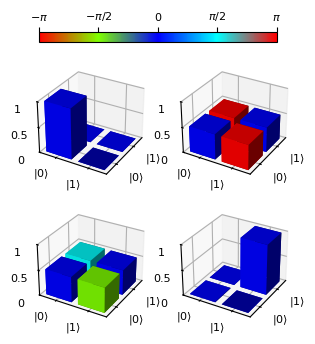

c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))
C:\Users\qipe\AppData\Local\Temp\ipykernel_8824\2353816787.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.92])
C:\Users\qipe\AppData\Local\Temp\ipykernel_8824\2353816787.py:40: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.92])


→ Using initial_labels (normal order)


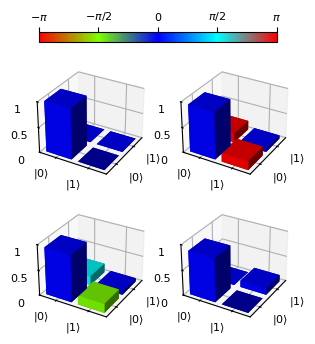

In [17]:
import matplotlib as mpl
from scipy.constants import pi

cmap = complex_phase_cmap()
norm = mpl.colors.Normalize(-pi, pi)

def plot_chi_selected(res, selected_labels, selected_labels_tex):
    chi_input_selected = [res["reduced_qubits"][k].full()[:2, :2] for k in selected_labels]

    fig, axes = plt.subplots(2, 2, figsize=(3.4,3.4), subplot_kw={"projection": "3d"})
    axes = axes.ravel()

    for i, label in enumerate(selected_labels):
        ax = axes[i]
        ysq.matrix_histogram_complex(qt.Qobj(chi_input_selected[i]), ax=ax, colorbar=False)

        ax.set_xticks([0, 1])
        ax.set_xticklabels([r"$|0\rangle$", r"$|1\rangle$"], fontsize=8, rotation=0)

        ax.set_yticks([0, 1])
        ax.set_yticklabels([r"$|0\rangle$", r"$|1\rangle$"], fontsize=8, rotation=0)

        ax.set_zticks([0, 0.5, 1.0])
        ax.set_zticklabels(["0", "0.5", "1"], fontsize=8)

        ax.tick_params(axis='x', pad=0)
        ax.tick_params(axis='y', pad=0)
        ax.tick_params(axis='z', pad=0)


    cbar_ax = fig.add_axes([0.15, 0.94, 0.7, 0.03])
    cb = mpl.colorbar.ColorbarBase(cbar_ax, cmap=cmap, norm=norm, orientation='horizontal')
    cb.set_ticks([-pi, -pi/2, 0, pi/2, pi])
    cb.set_ticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
    cb.ax.tick_params(labelsize=8)
    cb.ax.xaxis.set_ticks_position('top')
    cb.ax.xaxis.set_label_position('top')
    # cb.set_label("Phase (rad)")

    plt.tight_layout(rect=[0, 0, 1, 0.92])


m, n = 0, 3
res = evaluate_state_transfer_three_level(
    filename=filename,
    m=m,
    n=n,
    initial_labels=initial_labels,
    initial_labels_pi=initial_labels_pi,
    target_mode=3,
    plot_results=False 
)

selected_labels = ["g0", "g0+vc1", "g0+i*vc1", "vc1"]
selected_labels_tex = [r"$|g\rangle$", r"$|g\rangle-|e\rangle$", r"$|g\rangle+i|e\rangle$", r"$|e\rangle$"]

plot_chi_selected(res, selected_labels, selected_labels_tex)
# plt.savefig('Fig9a.pdf', bbox_inches='tight')
plt.show()

m, n = 3, 0
res = evaluate_state_transfer_three_level(
    filename=filename,
    m=m,
    n=n,
    initial_labels=initial_labels,
    initial_labels_pi=initial_labels_pi,
    target_mode=3,
    plot_results=False 
)

selected_labels = ["g0", "g0-vc1", "g0-i*vc1", "vc1"]
selected_labels_tex = [r"$|g\rangle$", r"$|g\rangle-|e\rangle$", r"$|g\rangle+i|e\rangle$", r"$|e\rangle$"]

plot_chi_selected(res, selected_labels, selected_labels_tex)
# plt.savefig('Fig9b.pdf', bbox_inches='tight')
plt.show()